# Imports

In [3]:
# %matplotlib qt5

import numpy as np
import matplotlib.pyplot as plt
from pycolleff.longitudinal_equilibrium import (
    ImpedanceSource,
    LongitudinalEquilibrium,
)

from pycolleff.rings import maxiv, als, half, sirius

from pycolleff.longitudinal_equilibrium import _mytrapz

from pycolleff.colleff import Ring

import matplotlib as mplt
import matplotlib.cm as cmap

import scienceplots
from itertools import product

mplt.style.use("science")

plt.rcParams.update(
    {
        "font.size": 18,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
    }
)

plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.right"] = False
plt.rcParams["ytick.direction"] = "out"
plt.rcParams["xtick.top"] = False

c = 299_792_458

# Methods

In [9]:
def calc_equilibrium_for_fixed_detuning(
    ring, mcav, hcav, current, detune, longeq=None
):
    """Calculate the equilibrium for a fixed cavity and current."""
    h = ring.harm_num
    ring.total_current = current
    fill = np.ones(h) / h

    if longeq is None:
        longeq = LongitudinalEquilibrium(
            ring=ring,
            impedance_sources=[
                mcav, hcav,
            ],
            fillpattern=fill,
        )
        longeq.feedback_on = False
        longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb / 2
        # longeq.zgrid = np.linspace(-0.9, 0.9, 2001) * ring.rf_lamb/2
    else:
        longeq.ring = ring
        longeq.impedance_sources = [mcav, hcav]
        longeq.ring.total_current = current
        longeq.fillpattern = fill
    longeq.identical_bunches = True

    longeq.impedance_sources[-1].detune_w = 2 * np.pi * detune
    _ = longeq.calc_longitudinal_equilibrium(
        niter=1_000, tol=1e-8, beta=0.1, print_flag=False, m=3
    )
    return longeq


def calc_equilibrium_for_flat_potential(
    ring, mcav, hcav, current, nr_iters=7, longeq=None
):
    """Calculate equilibrium to flat potential condition.

    This method will change the detune_angle of the cavity so that
    the beam induced voltage amplitude matches the flat potential
    condition.

    It will iterate a few times so that the form factor of the
    distribution converges.
    """
    h = ring.harm_num
    fill = np.ones(h) / h
    ring.total_current = current

    if longeq is None:
        longeq = LongitudinalEquilibrium(
            ring=ring,
            impedance_sources=[
                mcav, hcav,
            ],
            fillpattern=fill,
        )
        longeq.feedback_on = False
        longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb / 2
        # longeq.zgrid = np.linspace(-0.9, 0.9, 2001) * ring.rf_lamb/2
    else:
        longeq.ring = ring
        longeq.impedance_sources = [mcav, hcav]
        longeq.ring.total_current = current
        longeq.fillpattern = fill

    longeq.identical_bunches = True

    for _ in range(nr_iters):
        kharm = longeq.calc_harmonic_voltage_for_flat_potential(
            harm_rf=hcav.harm_rf)
        vharm = kharm * longeq.ring.gap_voltage
        angle = longeq.calc_detune_for_fixed_harmonic_voltage(
            vharm, Rs=hcav.loaded_shunt_impedance, harm_rf=hcav.harm_rf
        )
        hcav.detune_angle = angle
        longeq.impedance_sources[-1] = hcav
        print(f"detune: {hcav.detune_w/2/np.pi/1e3:.3f} kHz")

        _ = longeq.calc_longitudinal_equilibrium(
            niter=1000, tol=1e-8, beta=0.1, print_flag=False, m=3
        )
    return longeq


###############################################################################
def calc_lmci(
    longeq,
    cbmode=1,
    max_azi=2,
    max_rad=1,
    use_fokker=True,
    delete_m0=False,
    delete_m0k0=True,
    reduced=False,
):
    """Calculate LMCI for a given coupled bunch mode and equilibrium condition.

    Args:
        longeq: object from Longitudinal equilibrium class;
        cbmode: coupled-bunch mode to evaluate must be in range [0, h-1].
            Defaults to 1, which is the mode of PTBL instability;
        max_azi: maximum azimuthal mode to consider in expansion.
            Detaults to 2. Found to be enough to explain PTBL instability;
        max_azi: maximum radial mode to consider in expansion. Defaults to 1.
            Also found to be enough to explain PTBL instability.

    Returns:
        eigenfreq: complex coherent eigen angular frequencies in [rad/s];
        freqshift: frequency of the most unstable mode in [Hz];
        grate: growth rate of the most unstable mode in [1/s];
        sync_freq: incoherent synchrotron frequency used in calculations [Hz];
        peak_hvolt: peak voltage of harmonic cavity [V].

    """
    mcav = longeq.impedance_sources[0]
    hcav = longeq.impedance_sources[-1]
    hvolt = hcav.calc_induced_voltage(longeq)
    peak_hvolt = np.max(np.abs(hvolt[0, :]))
    peak_mvolt = mcav.ref_amp

    print(f"current: {longeq.ring.total_current*1e3:.2f} mA")
    print(f"detune: {hcav.detune_w/2/np.pi/1e3:.3f} kHz")
    print(f"detune angle: {np.rad2deg(hcav.detune_angle):.1f} deg")
    print(f"R/Q: {hcav.shunt_impedance/hcav.Q:.1f} Ohm")
    print(f"HC voltage: {peak_hvolt/1e3:.1f} kV")
    ratio = peak_hvolt / peak_mvolt
    print(f"HC voltage ratio: {ratio:.3f}")

    wrf = longeq.ring.rf_ang_freq
    dist, pot = longeq.calc_distributions_from_voltage(longeq.total_voltage)
    z0, sigmaz = longeq.calc_moments(longeq.zgrid, dist[0])
    sigmaz = sigmaz[0]

    # Calculate the equivalent synchrotron frequency:
    # Equivalent single-rf (quadratic) potential.
    # Sync. frequency determined by bunch length
    sync_freq = longeq.ring.espread * longeq.ring.mom_comp * c
    sync_freq /= sigmaz * 2 * np.pi
    print(f"FREQ BY BUNCH LENGTH: {sync_freq:.5f} Hz")

#     Sync. freq. by voltage derivative average by distribution
#     sync_data = longeq.calc_synchrotron_frequency(
#         method='derivative', nrpts=500, max_amp=5)
#     sync_freq = sync_data['avg_sync_freq']
#     print(f"FREQ BY V'(z): {sync_freq:.5f} Hz")

#     # Amplitude-dependent Sync. freq. averaged by action distribution
#     sync_data = longeq.calc_synchrotron_frequency(
#         method='action', nrpts=500, max_amp=5)
#     sync_freq = sync_data['avg_sync_freq']
#     print(f"FREQ BY w(J): {sync_freq:.5f} Hz")

    longeq.ring.sync_tune = sync_freq / longeq.ring.rev_freq
    longeq.ring.bunlen = sigmaz

    print(
        f"sync. freq.: {longeq.ring.sync_tune * longeq.ring.rev_freq:.3f} Hz"
    )
    print(f"bunch length: {longeq.ring.bunlen*1e3:.3f} mm")

    # Calculate Vlasov's equation eigen-frequencies:
    wrf = longeq.ring.rf_ang_freq
    eigenfreq, *_ = longeq.calc_mode_coupling(
        w=[-10 * wrf, +10 * wrf],
        cbmode=cbmode,
        max_azi=max_azi,
        max_rad=max_rad,
        use_fokker=use_fokker,
        delete_m0=delete_m0,
        delete_m0k0=delete_m0k0,
        reduced=reduced,
    )

    # Find most unstable mode:
    idx = np.argmax(eigenfreq.imag)
    freqshift = eigenfreq.real[idx] / 2 / np.pi
    grate = eigenfreq.imag[idx]
    if reduced:
        # Subtract radiation damping rate from "reduced" simulation:
        grate -= 1 / longeq.ring.dampte

    print(f"{longeq.ring.total_current*1e3:.2f} mA. Most unstable mode:")
    print(f"    frequency: {freqshift:.2f} Hz")
    print(f"    growth rate: {grate:.2f} 1/s")
    print("\n")
    return eigenfreq, freqshift, grate, sync_freq, peak_hvolt


def calc_lmci_scan_current(
    ring,
    mcav,
    hcav,
    current_scan,
    max_azi=3,
    max_rad=2,
    use_fokker=True,
    delete_m0=False,
    delete_m0k0=True,
    reduced=False,
    stop_when_unstable=False,
):
    """Calculate equilibrium and solve Vlasov equation for a current set.

    The cavity will be detuned to flat potential condition at each current.

    """
    growths, shifts, syncdata, peak_hvolts, eigenfreqs = [], [], [], [], []
    longeq = None
    cbmode = 1
    # cbpmode = ring.harm_num-1
    for i, current in enumerate(current_scan):
        longeq = calc_equilibrium_for_flat_potential(
            ring,
            mcav,
            hcav,
            current=current,
            nr_iters=10,
            longeq=longeq,
        )
        eigenfreq, tuneshift, grate, sync_freq, peak_hvolt = calc_lmci(
            longeq,
            cbmode=cbmode,
            max_azi=max_azi,
            max_rad=max_rad,
            use_fokker=use_fokker,
            delete_m0=delete_m0,
            delete_m0k0=delete_m0k0,
            reduced=reduced,
        )
        growths.append(grate)
        shifts.append(tuneshift)
        syncdata.append(sync_freq)
        peak_hvolts.append(peak_hvolt)
        eigenfreqs.append(eigenfreq)

        if stop_when_unstable and grate > 0:
            break
    growths = np.array(growths)
    shifts = np.array(shifts)
    syncdata = np.array(syncdata)
    peak_hvolts = np.array(peak_hvolts)
    eigenfreqs = np.array(eigenfreqs)
    return growths, shifts, syncdata, peak_hvolts, eigenfreqs


def calc_lmci_scan_detuning(
    ring,
    mcav,
    hcav,
    current,
    detuning_scan,
    max_azi=3,
    max_rad=2,
    use_fokker=True,
    delete_m0=False,
    delete_m0k0=True,
    reduced=False,
    stop_when_unstable=False,
):
    """Calculate equilibrium and solve Vlasov equation for a detuning set."""
    growths, shifts, syncdata, peak_hvolts = [], [], [], []
    longeq = None
    cbmode = 1
    # cbpmode = ring.harm_num-1
    for i, detune in enumerate(detuning_scan):
        longeq = calc_equilibrium_for_fixed_detuning(
            ring,
            mcav,
            hcav,
            current,
            detune=detune,
            longeq=longeq,
        )
        eigenfreq, tuneshift, grate, sync_freq, peak_hvolt = calc_lmci(
            longeq,
            cbmode=cbmode,
            max_azi=max_azi,
            max_rad=max_rad,
            use_fokker=use_fokker,
            delete_m0=delete_m0,
            delete_m0k0=delete_m0k0,
            reduced=reduced,
        )
        growths.append(grate)
        shifts.append(tuneshift)
        syncdata.append(sync_freq)
        peak_hvolts.append(peak_hvolt)

        if stop_when_unstable and grate > 0:
            break
    growths = np.array(growths)
    shifts = np.array(shifts)
    syncdata = np.array(syncdata)
    peak_hvolts = np.array(peak_hvolts)
    return growths, shifts, syncdata, peak_hvolts, eigenfreq

# MAX-IV

In [10]:
ring = maxiv.create_ring(energy=3)
# ring.gap_voltage = 1.397e6

ring.gap_voltage = 1.0e6
ring.total_current = 300e-3
print(ring)

Lattice Version             :     MAX-IV-3GeV     
Circumference [m]           :       527.999       
Revolution Period [us]      :        1.761        
Revolution Frequency [kHz]  :       567.790       
Energy [GeV]                :        3.000        
U0 [keV]                    :       363.800       
Vgap [MV]                   :        1.000        
Momentum Compaction         :       3.06e-04      
Harmonic Number             :         176         
Current [mA]                :       300.000       
Current per Bunch [mA]      :        1.705        
Synchrotron Tune            :       0.00164       
Tunes x/y                   :    16.280/42.200    
Chromaticities x/y          :     1.000/1.000     
Damping Times x/y/e [ms]    :   15.7/ 29.0 /25.2  
Energy Spread [%]           :        0.0769       
Bunch Length [mm]           :        10.694       



In [11]:
mcav = ImpedanceSource()
Rs0 = 1.71e6
Q0 = 20_248
beta = 4.5
ncavs = 5

mcav.harm_rf = 1
mcav.shunt_impedance = Rs0 * ncavs
mcav.Q = Q0
mcav.beta_coupling = beta

twopi = 2*np.pi
wrf = twopi*ring.rf_freq
mcav.ang_freq_rf = wrf
mcav.res_ang_freq = mcav.harm_rf*wrf

mcav.ref_amp = ring.gap_voltage
mcav.ref_phase = ring.sync_phase
mcav.feedback_on = True

df = mcav.optimum_detuning_freq(beam_current=ring.total_current)
mcav.detune_w = twopi*df

mcav.active_passive = ImpedanceSource.ActivePassive.Active

# If you do not want to worry about the details of the voltage gap
# control system, you can use SIRIUS parameters below.
delay = 1.9e-6
ki = 0.01
kp = 2.96e-6
kd = 0
gain = 1 * 0
mcav.loop_ctrl_ang_freq = twopi * ring.rf_freq
mcav.loop_ctrl_kpid = [kp, ki, kd]
mcav.loop_ctrl_overall_gain = gain
mcav.loop_ctrl_delay = delay
mcav.loop_ctrl_transfer = mcav.pid_transfer_func
mcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
# mcav.calc_method = ImpedanceSource.Methods.Wake

print(mcav)

calc_method              : ImpedanceDFT  
active_passive           : Active  
ang_freq_rf              : 627.88  [Mrad/s]
res_ang_freq             : 627.81  [Mrad/s]
shunt_impedance          : 8.55  [MOhm]
Q                        : 2.02e+04  
RoverQ                   : 422.26  [Ohm]
beta_coupling            : 4.50  
harm_rf                  : 1.00  
detune_angle             : -0.72  [rad]
detune_freq              : -11.79  [kHz]
detune_w                 : -74.09  [krad/s]
alpha                    : 85266.69  [rad/s]
res_ang_freq_bar         : 627.81  [Mrad/s]
loaded_shunt_impedance   : 1.55  [MOhm]
loaded_Q                 : 3.68e+03  
feedback_on              : True  
feedback_method          : Phasor  
ref_amp                  : 1000.00  [kV]
ref_phase                : 158.67  [deg]



In [12]:
hcav = ImpedanceSource()
hcav.harm_rf = 3
hcav.Q = 20_800
# ncavs = 3

# simulating 2 harmonic cavities
ncavs = 2
hcav.shunt_impedance = 2.75e6 * ncavs

twopi = 2 * np.pi
hcav.ang_freq_rf = twopi * ring.rf_freq
hcav.res_ang_freq = hcav.harm_rf * hcav.ang_freq_rf

hcav.detune_w = twopi * 85e3
hcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
hcav.active_passive = ImpedanceSource.ActivePassive.Passive
print(hcav)

calc_method              : ImpedanceDFT  
active_passive           : Passive  
ang_freq_rf              : 627.88  [Mrad/s]
res_ang_freq             : 1884.19  [Mrad/s]
shunt_impedance          : 5.50  [MOhm]
Q                        : 2.08e+04  
RoverQ                   : 264.42  [Ohm]
beta_coupling            : 0.00  
harm_rf                  : 3.00  
detune_angle             : 1.49  [rad]
detune_freq              : 85.00  [kHz]
detune_w                 : 534.07  [krad/s]
alpha                    : 45293.01  [rad/s]
res_ang_freq_bar         : 1884.19  [Mrad/s]



In [13]:
current_scan = np.linspace(50, 500, 20) * 1e-3
grate, freq, sync_freq, peak_hvolt, eigs = calc_lmci_scan_current(
    ring,
    mcav,
    hcav,
    current_scan,
    max_azi=2,
    max_rad=1,
    use_fokker=True,
    delete_m0=True,
    delete_m0k0=True,
    reduced=False,
    stop_when_unstable=False,
)

detune: 10.641 kHz
detune: 10.278 kHz
detune: 10.214 kHz
detune: 10.200 kHz
detune: 10.197 kHz
detune: 10.196 kHz
detune: 10.196 kHz
detune: 10.196 kHz
detune: 10.196 kHz
detune: 10.196 kHz
current: 50.00 mA
detune: 10.196 kHz
detune angle: 54.7 deg
R/Q: 264.4 Ohm
HC voltage: 307.6 kV
HC voltage ratio: 0.308
FREQ BY BUNCH LENGTH: 278.99651 Hz
sync. freq.: 278.997 Hz
bunch length: 40.243 mm
50.00 mA. Most unstable mode:
    frequency: 276.86 Hz
    growth rate: -39.62 1/s


detune: 16.930 kHz
detune: 16.657 kHz
detune: 16.560 kHz
detune: 16.523 kHz
detune: 16.508 kHz
detune: 16.502 kHz
detune: 16.500 kHz
detune: 16.499 kHz
detune: 16.498 kHz
detune: 16.498 kHz
current: 73.68 mA
detune: 16.498 kHz
detune angle: 66.4 deg
R/Q: 264.4 Ohm
HC voltage: 307.6 kV
HC voltage ratio: 0.308
FREQ BY BUNCH LENGTH: 215.61407 Hz
sync. freq.: 215.614 Hz
bunch length: 52.073 mm
73.68 mA. Most unstable mode:
    frequency: 210.40 Hz
    growth rate: -39.47 1/s


detune: 22.673 kHz
detune: 22.560 kHz
detune

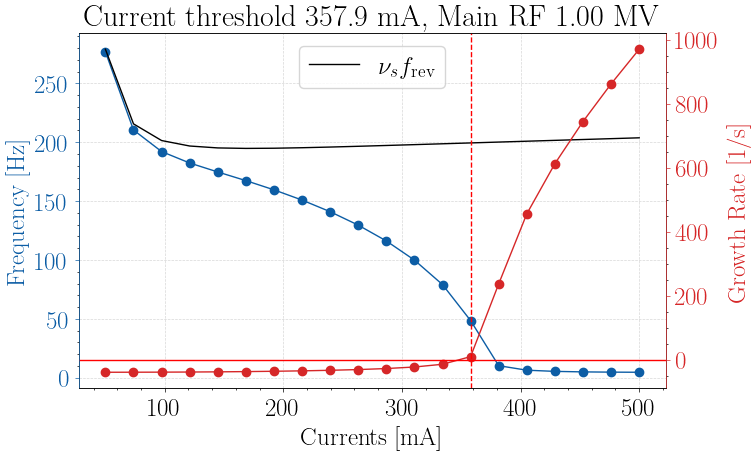

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ay = ax.twinx()
ax.plot(current_scan * 1e3, freq, "o-")
ax.plot(current_scan * 1e3, sync_freq, color="k", label=r"$\nu_sf_\text{rev}$")
ay.plot(current_scan * 1e3, np.array(grate), "o-", color="tab:red")
thre = current_scan[np.argmax(grate > 0)] * 1e3
ay.axhline(0, ls='-', color='r')
ay.axvline(thre, ls='--', color='r')
ay.set_title(f"Current threshold {thre:.1f} mA, Main RF {ring.gap_voltage/1e6:.2f} MV")

ay.grid(False)
ay.spines["right"].set_color("tab:red")
# plt.setp(ay.yaxis.get_ticklabels(), color='tab:red')
ay.tick_params(axis="y", colors="tab:red")

ay.spines["left"].set_color("C0")
plt.setp(ax.yaxis.get_ticklabels(), color="tab:red")
ax.tick_params(axis="y", colors="C0")

ax.legend(loc="upper center", frameon=True)
# ay.legend(loc="center left", frameon=True)
ax.set_ylabel("Frequency [Hz]", color="C0")
ax.set_xlabel("Currents [mA]")
ay.set_ylabel("Growth Rate [1/s]", color="tab:red")
fig.tight_layout()
plt.show()

In [15]:
current_scan = np.linspace(300, 400, 51) * 1e-3
main_rf = np.linspace(900, 1100, 11) * 1e3
thresholds = []

for rf in main_rf:
    ring.gap_voltage = rf
    mcav.ref_amp = ring.gap_voltage
    mcav.ref_phase = ring.sync_phase
    grate, freq, sync_freq, peak_hvolt, eigs = calc_lmci_scan_current(
        ring,
        mcav,
        hcav,
        current_scan,
        max_azi=2,
        max_rad=1,
        use_fokker=True,
        delete_m0=True,
        delete_m0k0=True,
        reduced=False,
        stop_when_unstable=False,
    )
#     idx_unstable = np.argmax(grate > 0)
#     idx_unstable = np.argmax(grate > 1/ring.dampte)
#     thre = current_scan[idx_unstable] * 1e3
#     current_scan = current_scan[idx_unstable:]
    thre = current_scan[np.argmax(grate > 0)] * 1e3
    print(rf/1000, thre)
    thresholds.append(thre)

thresholds = np.array(thresholds)

detune: 87.174 kHz
detune: 83.763 kHz
detune: 82.593 kHz
detune: 82.100 kHz
detune: 81.878 kHz
detune: 81.774 kHz
detune: 81.726 kHz
detune: 81.703 kHz
detune: 81.693 kHz
detune: 81.687 kHz
current: 300.00 mA
detune: 81.687 kHz
detune angle: 85.0 deg
R/Q: 264.4 Ohm
HC voltage: 271.1 kV
HC voltage ratio: 0.301
FREQ BY BUNCH LENGTH: 192.27961 Hz
sync. freq.: 192.280 Hz
bunch length: 58.392 mm
300.00 mA. Most unstable mode:
    frequency: 83.38 Hz
    growth rate: -18.50 1/s


detune: 82.234 kHz
detune: 82.235 kHz
detune: 82.235 kHz
detune: 82.235 kHz
detune: 82.236 kHz
detune: 82.236 kHz
detune: 82.236 kHz
detune: 82.236 kHz
detune: 82.236 kHz
detune: 82.236 kHz
current: 302.00 mA
detune: 82.236 kHz
detune angle: 85.0 deg
R/Q: 264.4 Ohm
HC voltage: 271.1 kV
HC voltage ratio: 0.301
FREQ BY BUNCH LENGTH: 192.30941 Hz
sync. freq.: 192.309 Hz
bunch length: 58.383 mm
302.00 mA. Most unstable mode:
    frequency: 81.28 Hz
    growth rate: -17.58 1/s


detune: 82.785 kHz
detune: 82.787 kHz
detu

detune: 94.404 kHz
detune: 94.404 kHz
detune: 94.404 kHz
detune: 94.404 kHz
detune: 94.404 kHz
detune: 94.404 kHz
detune: 94.404 kHz
current: 346.00 mA
detune: 94.404 kHz
detune angle: 85.6 deg
R/Q: 264.4 Ohm
HC voltage: 271.1 kV
HC voltage ratio: 0.301
FREQ BY BUNCH LENGTH: 193.76414 Hz
sync. freq.: 193.764 Hz
bunch length: 57.945 mm
346.00 mA. Most unstable mode:
    frequency: 12.08 Hz
    growth rate: 177.13 1/s


detune: 94.953 kHz
detune: 94.955 kHz
detune: 94.956 kHz
detune: 94.957 kHz
detune: 94.957 kHz
detune: 94.957 kHz
detune: 94.957 kHz
detune: 94.957 kHz
detune: 94.957 kHz
detune: 94.957 kHz
current: 348.00 mA
detune: 94.957 kHz
detune angle: 85.7 deg
R/Q: 264.4 Ohm
HC voltage: 271.1 kV
HC voltage ratio: 0.301
FREQ BY BUNCH LENGTH: 193.82952 Hz
sync. freq.: 193.830 Hz
bunch length: 57.925 mm
348.00 mA. Most unstable mode:
    frequency: 10.81 Hz
    growth rate: 205.72 1/s


detune: 95.506 kHz
detune: 95.509 kHz
detune: 95.510 kHz
detune: 95.510 kHz
detune: 95.511 kHz
detu

detune: 81.573 kHz
detune: 80.445 kHz
detune: 79.970 kHz
detune: 79.755 kHz
detune: 79.656 kHz
detune: 79.610 kHz
detune: 79.588 kHz
detune: 79.577 kHz
detune: 79.572 kHz
current: 300.00 mA
detune: 79.572 kHz
detune angle: 84.8 deg
R/Q: 264.4 Ohm
HC voltage: 278.5 kV
HC voltage ratio: 0.303
FREQ BY BUNCH LENGTH: 193.38829 Hz
sync. freq.: 193.388 Hz
bunch length: 58.058 mm
300.00 mA. Most unstable mode:
    frequency: 89.07 Hz
    growth rate: -20.51 1/s


detune: 80.105 kHz
detune: 80.106 kHz
detune: 80.106 kHz
detune: 80.106 kHz
detune: 80.106 kHz
detune: 80.106 kHz
detune: 80.106 kHz
detune: 80.106 kHz
detune: 80.106 kHz
detune: 80.106 kHz
current: 302.00 mA
detune: 80.106 kHz
detune angle: 84.9 deg
R/Q: 264.4 Ohm
HC voltage: 278.5 kV
HC voltage ratio: 0.303
FREQ BY BUNCH LENGTH: 193.41671 Hz
sync. freq.: 193.417 Hz
bunch length: 58.049 mm
302.00 mA. Most unstable mode:
    frequency: 87.14 Hz
    growth rate: -19.75 1/s


detune: 80.641 kHz
detune: 80.643 kHz
detune: 80.644 kHz
detu

detune: 93.578 kHz
detune: 93.579 kHz
detune: 93.579 kHz
detune: 93.579 kHz
detune: 93.579 kHz
current: 352.00 mA
detune: 93.579 kHz
detune angle: 85.6 deg
R/Q: 264.4 Ohm
HC voltage: 278.5 kV
HC voltage ratio: 0.303
FREQ BY BUNCH LENGTH: 195.04629 Hz
sync. freq.: 195.046 Hz
bunch length: 57.564 mm
352.00 mA. Most unstable mode:
    frequency: 12.45 Hz
    growth rate: 172.57 1/s


detune: 94.113 kHz
detune: 94.116 kHz
detune: 94.117 kHz
detune: 94.117 kHz
detune: 94.118 kHz
detune: 94.118 kHz
detune: 94.118 kHz
detune: 94.118 kHz
detune: 94.118 kHz
detune: 94.118 kHz
current: 354.00 mA
detune: 94.118 kHz
detune angle: 85.6 deg
R/Q: 264.4 Ohm
HC voltage: 278.5 kV
HC voltage ratio: 0.303
FREQ BY BUNCH LENGTH: 195.11085 Hz
sync. freq.: 195.111 Hz
bunch length: 57.545 mm
354.00 mA. Most unstable mode:
    frequency: 11.11 Hz
    growth rate: 201.28 1/s


detune: 94.653 kHz
detune: 94.655 kHz
detune: 94.656 kHz
detune: 94.656 kHz
detune: 94.657 kHz
detune: 94.657 kHz
detune: 94.657 kHz
detu

detune: 77.578 kHz
detune: 77.573 kHz
current: 300.00 mA
detune: 77.573 kHz
detune angle: 84.7 deg
R/Q: 264.4 Ohm
HC voltage: 285.8 kV
HC voltage ratio: 0.304
FREQ BY BUNCH LENGTH: 194.48379 Hz
sync. freq.: 194.484 Hz
bunch length: 57.730 mm
300.00 mA. Most unstable mode:
    frequency: 94.27 Hz
    growth rate: -22.13 1/s


detune: 78.093 kHz
detune: 78.093 kHz
detune: 78.094 kHz
detune: 78.094 kHz
detune: 78.094 kHz
detune: 78.094 kHz
detune: 78.094 kHz
detune: 78.094 kHz
detune: 78.094 kHz
detune: 78.094 kHz
current: 302.00 mA
detune: 78.094 kHz
detune angle: 84.7 deg
R/Q: 264.4 Ohm
HC voltage: 285.8 kV
HC voltage ratio: 0.304
FREQ BY BUNCH LENGTH: 194.51078 Hz
sync. freq.: 194.511 Hz
bunch length: 57.722 mm
302.00 mA. Most unstable mode:
    frequency: 92.48 Hz
    growth rate: -21.49 1/s


detune: 78.616 kHz
detune: 78.618 kHz
detune: 78.619 kHz
detune: 78.619 kHz
detune: 78.619 kHz
detune: 78.619 kHz
detune: 78.619 kHz
detune: 78.619 kHz
detune: 78.619 kHz
detune: 78.619 kHz
curr

...

detune: 75.314 kHz
detune: 75.314 kHz
detune: 75.315 kHz
detune: 75.315 kHz
detune: 75.315 kHz
detune: 75.315 kHz
detune: 75.315 kHz
current: 334.00 mA
detune: 75.315 kHz
detune angle: 84.5 deg
R/Q: 264.4 Ohm
HC voltage: 329.2 kV
HC voltage ratio: 0.311
FREQ BY BUNCH LENGTH: 201.75949 Hz
sync. freq.: 201.759 Hz
bunch length: 55.649 mm
334.00 mA. Most unstable mode:
    frequency: 95.18 Hz
    growth rate: -20.58 1/s


detune: 75.770 kHz
detune: 75.771 kHz
detune: 75.772 kHz
detune: 75.772 kHz
detune: 75.772 kHz
detune: 75.772 kHz
detune: 75.772 kHz
detune: 75.773 kHz
detune: 75.773 kHz
detune: 75.773 kHz
current: 336.00 mA
detune: 75.773 kHz
detune angle: 84.6 deg
R/Q: 264.4 Ohm
HC voltage: 329.2 kV
HC voltage ratio: 0.311
FREQ BY BUNCH LENGTH: 201.81749 Hz
sync. freq.: 201.817 Hz
bunch length: 55.633 mm
336.00 mA. Most unstable mode:
    frequency: 93.55 Hz
    growth rate: -19.96 1/s


detune: 76.228 kHz
detune: 76.229 kHz
detune: 76.230 kHz
detune: 76.230 kHz
detune: 76.230 kHz
detu

detune: 88.142 kHz
current: 390.00 mA
detune: 88.142 kHz
detune angle: 85.3 deg
R/Q: 264.4 Ohm
HC voltage: 329.2 kV
HC voltage ratio: 0.311
FREQ BY BUNCH LENGTH: 203.40821 Hz
sync. freq.: 203.408 Hz
bunch length: 55.198 mm
390.00 mA. Most unstable mode:
    frequency: 19.48 Hz
    growth rate: 101.56 1/s


detune: 88.597 kHz
detune: 88.598 kHz
detune: 88.599 kHz
detune: 88.600 kHz
detune: 88.600 kHz
detune: 88.600 kHz
detune: 88.600 kHz
detune: 88.600 kHz
detune: 88.600 kHz
detune: 88.600 kHz
current: 392.00 mA
detune: 88.600 kHz
detune angle: 85.3 deg
R/Q: 264.4 Ohm
HC voltage: 329.2 kV
HC voltage ratio: 0.311
FREQ BY BUNCH LENGTH: 203.46769 Hz
sync. freq.: 203.468 Hz
bunch length: 55.181 mm
392.00 mA. Most unstable mode:
    frequency: 16.36 Hz
    growth rate: 130.87 1/s


detune: 89.055 kHz
detune: 89.057 kHz
detune: 89.057 kHz
detune: 89.058 kHz
detune: 89.058 kHz
detune: 89.058 kHz
detune: 89.058 kHz
detune: 89.058 kHz
detune: 89.058 kHz
detune: 89.058 kHz
current: 394.00 mA
detu

338.00 mA. Most unstable mode:
    frequency: 96.59 Hz
    growth rate: -20.80 1/s


detune: 75.087 kHz
detune: 75.088 kHz
detune: 75.089 kHz
detune: 75.089 kHz
detune: 75.089 kHz
detune: 75.089 kHz
detune: 75.089 kHz
detune: 75.089 kHz
detune: 75.089 kHz
detune: 75.089 kHz
current: 340.00 mA
detune: 75.089 kHz
detune angle: 84.5 deg
R/Q: 264.4 Ohm
HC voltage: 336.3 kV
HC voltage ratio: 0.311
FREQ BY BUNCH LENGTH: 202.93193 Hz
sync. freq.: 202.932 Hz
bunch length: 55.327 mm
340.00 mA. Most unstable mode:
    frequency: 94.99 Hz
    growth rate: -20.21 1/s


detune: 75.535 kHz
detune: 75.537 kHz
detune: 75.537 kHz
detune: 75.537 kHz
detune: 75.538 kHz
detune: 75.538 kHz
detune: 75.538 kHz
detune: 75.538 kHz
detune: 75.538 kHz
detune: 75.538 kHz
current: 342.00 mA
detune: 75.538 kHz
detune angle: 84.5 deg
R/Q: 264.4 Ohm
HC voltage: 336.3 kV
HC voltage ratio: 0.311
FREQ BY BUNCH LENGTH: 202.98902 Hz
sync. freq.: 202.989 Hz
bunch length: 55.312 mm
342.00 mA. Most unstable mode:
    frequen

detune: 87.652 kHz
detune: 87.652 kHz
detune: 87.652 kHz
detune: 87.652 kHz
current: 396.00 mA
detune: 87.652 kHz
detune angle: 85.3 deg
R/Q: 264.4 Ohm
HC voltage: 336.3 kV
HC voltage ratio: 0.311
FREQ BY BUNCH LENGTH: 204.55897 Hz
sync. freq.: 204.559 Hz
bunch length: 54.887 mm
396.00 mA. Most unstable mode:
    frequency: 19.53 Hz
    growth rate: 102.63 1/s


detune: 88.097 kHz
detune: 88.099 kHz
detune: 88.100 kHz
detune: 88.100 kHz
detune: 88.100 kHz
detune: 88.100 kHz
detune: 88.100 kHz
detune: 88.100 kHz
detune: 88.100 kHz
detune: 88.100 kHz
current: 398.00 mA
detune: 88.100 kHz
detune angle: 85.3 deg
R/Q: 264.4 Ohm
HC voltage: 336.3 kV
HC voltage ratio: 0.311
FREQ BY BUNCH LENGTH: 204.61780 Hz
sync. freq.: 204.618 Hz
bunch length: 54.871 mm
398.00 mA. Most unstable mode:
    frequency: 16.44 Hz
    growth rate: 131.67 1/s


detune: 88.546 kHz
detune: 88.548 kHz
detune: 88.549 kHz
detune: 88.549 kHz
detune: 88.549 kHz
detune: 88.549 kHz
detune: 88.549 kHz
detune: 88.549 kHz
detu

detune: 74.877 kHz
detune: 74.878 kHz
detune: 74.878 kHz
detune: 74.878 kHz
detune: 74.878 kHz
detune: 74.878 kHz
detune: 74.878 kHz
detune: 74.878 kHz
current: 346.00 mA
detune: 74.878 kHz
detune angle: 84.5 deg
R/Q: 264.4 Ohm
HC voltage: 343.5 kV
HC voltage ratio: 0.312
FREQ BY BUNCH LENGTH: 204.08974 Hz
sync. freq.: 204.090 Hz
bunch length: 55.013 mm
346.00 mA. Most unstable mode:
    frequency: 94.78 Hz
    growth rate: -19.82 1/s


detune: 75.315 kHz
detune: 75.316 kHz
detune: 75.317 kHz
detune: 75.317 kHz
detune: 75.317 kHz
detune: 75.317 kHz
detune: 75.317 kHz
detune: 75.317 kHz
detune: 75.317 kHz
detune: 75.317 kHz
current: 348.00 mA
detune: 75.317 kHz
detune angle: 84.5 deg
R/Q: 264.4 Ohm
HC voltage: 343.5 kV
HC voltage ratio: 0.312
FREQ BY BUNCH LENGTH: 204.14596 Hz
sync. freq.: 204.146 Hz
bunch length: 54.998 mm
348.00 mA. Most unstable mode:
    frequency: 93.14 Hz
    growth rate: -19.18 1/s


detune: 75.754 kHz
detune: 75.756 kHz
detune: 75.756 kHz
detune: 75.757 kHz
detu

In [16]:
# From PRAB paper https://journals.aps.org/prab/pdf/10.1103/PhysRevAccelBeams.27.044403

maxiv_data_curr = [399, 394, 390, 385, 380, 375, 370, 365, 360]
maxiv_data_main_rf = [1070, 1050, 1035, 1020, 1010, 995, 985, 965, 945]

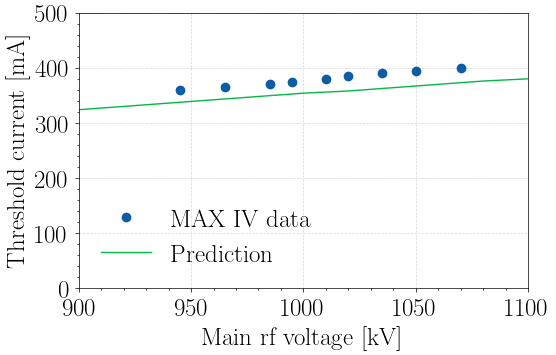

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(maxiv_data_main_rf, maxiv_data_curr, 'o', label='MAX IV data')
plt.plot(main_rf/1e3, thresholds, label='Prediction')
plt.legend()
# use the same y-scale of Fig. 11 from the paper.
plt.ylim([0, 500])
plt.xlim([900, 1100])
plt.xlabel('Main rf voltage [kV]')
plt.ylabel('Threshold current [mA]')
plt.tight_layout()
plt.show()

In [18]:
current = 360e-3
detune_scan = np.linspace(150, 80, 31) * 1e3
ring.gap_voltage = 1.0e6
mcav.ref_amp = ring.gap_voltage
mcav.ref_phase = ring.sync_phase

grate, freq, sync_freq, peak_hvolt, eigs = calc_lmci_scan_detuning(
    ring,
    mcav,
    hcav,
    current,
    detune_scan,
    max_azi=2,
    max_rad=1,
    use_fokker=True,
    delete_m0=True,
    delete_m0k0=True,
    reduced=False,
    stop_when_unstable=False,
)

current: 360.00 mA
detune: 150.000 kHz
detune angle: 87.2 deg
R/Q: 264.4 Ohm
HC voltage: 188.8 kV
HC voltage ratio: 0.189
FREQ BY BUNCH LENGTH: 594.63310 Hz
sync. freq.: 594.633 Hz
bunch length: 18.882 mm
360.00 mA. Most unstable mode:
    frequency: 554.85 Hz
    growth rate: -33.72 1/s


current: 360.00 mA
detune: 147.667 kHz
detune angle: 87.2 deg
R/Q: 264.4 Ohm
HC voltage: 191.8 kV
HC voltage ratio: 0.192
FREQ BY BUNCH LENGTH: 587.61143 Hz
sync. freq.: 587.611 Hz
bunch length: 19.107 mm
360.00 mA. Most unstable mode:
    frequency: 547.96 Hz
    growth rate: -33.77 1/s


current: 360.00 mA
detune: 145.333 kHz
detune angle: 87.2 deg
R/Q: 264.4 Ohm
HC voltage: 194.8 kV
HC voltage ratio: 0.195
FREQ BY BUNCH LENGTH: 580.28479 Hz
sync. freq.: 580.285 Hz
bunch length: 19.349 mm
360.00 mA. Most unstable mode:
    frequency: 540.74 Hz
    growth rate: -33.82 1/s


current: 360.00 mA
detune: 143.000 kHz
detune angle: 87.1 deg
R/Q: 264.4 Ohm
HC voltage: 197.9 kV
HC voltage ratio: 0.198
FREQ 

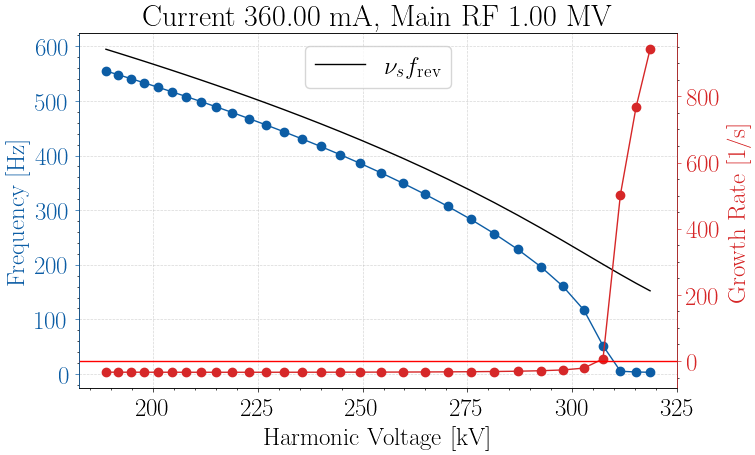

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ay = ax.twinx()

norm = 1
ax.plot(peak_hvolt * 1e-3 / norm, freq, "o-")
ax.plot(peak_hvolt * 1e-3 / norm, sync_freq, color="k", label=r"$\nu_sf_{\text{rev}}$")
ay.plot(peak_hvolt * 1e-3 / norm, grate, "o-", color="tab:red")

ay.axhline(0, color='r')
ax.set_title(f"Current {current*1e3:.2f} mA, Main RF {ring.gap_voltage/1e6:.2f} MV")
# ax.axvline(448.181)

ay.grid(False)
ay.spines["right"].set_color("tab:red")
# plt.setp(ay.yaxis.get_ticklabels(), color='tab:red')
ay.tick_params(axis="y", colors="tab:red")

ay.spines["left"].set_color("C0")
plt.setp(ax.yaxis.get_ticklabels(), color="tab:red")
ax.tick_params(axis="y", colors="C0")

ax.legend(loc="upper center", frameon=True)
ax.set_ylabel("Frequency [Hz]", color="C0")
ax.set_xlabel("Harmonic Voltage [kV]")
ay.set_ylabel("Growth Rate [1/s]", color="tab:red")
fig.tight_layout()
plt.show()